# Scenario 1

## Environment implementation

In [1]:
class environment:
    def __init__(self):
        # [[(Row_Payoff, Col_Payoff), ...], ...]
        self.payoff_matrix = [
            [(1, 2), (1, 1)],
            [(1,1), (2,1)]
        ]

      # Define types: X (Column players) and Y (Row players)
        self.agent_types = {
            "X1": "X", "X2": "X", "X3": "X", "X4": "X", "X5": "X",
            "Y1": "Y", "Y2": "Y"
        }

        # Define the djacency graph edges
        self.graph = {
            "X1": ["Y1"],
            "X2": ["Y2"],
            "Y1": ["X1", "X3", "X4"],
            "Y2": ["X2", "X3", "X5"],
            "X3": ["Y1", "Y2", "X4", "X5"],
            "X4": ["Y1", "X3"],
            "X5": ["Y2", "X3"]
        }

        # Epsilon decay parameters

    def reset(self):
        pass

    def step(self, action_matrix):
        """
        Distributes rewards.
        action_matrix = {agent_name: agent_action}
        """

        rewards = {name: 0 for name in self.graph.keys()}

        # Traverse each agent in the graph
        for each_agent in self.graph.keys():
            # Traverse each opponents and calculate rewards
            for each_opponent in self.graph[each_agent]:
                # Extract actions
                act_agent = action_matrix[each_agent] - 1
                act_opp = action_matrix[each_opponent] - 1

                # Extract row column combo from payoff matrix
                if "Y" in each_agent:
                    row_idx, col_idx = act_agent, act_opp

                elif "Y" in each_opponent:
                    row_idx, col_idx = act_opp, act_agent

                else:
                    # Same pair of agents: X vs X
                    row_idx, col_idx = act_agent, act_opp

                # Extract payoff block
                payoff_block = self.payoff_matrix[row_idx][col_idx]

                if "Y" in each_agent:
                    rewards[each_agent] += payoff_block[0]
                else:
                    rewards[each_agent] += payoff_block[1]

        return rewards

## Agent implementation 

Q-learning algorithm with e-greedy exploration function.

In [10]:
# Q-learning with e-greedy
import numpy as np

class QLearningAgent():
    def __init__(self, agent_name, agent_type, actions=[1, 2], epsilon_init=1.0, epsilon_threshold=0.0, epsilon_decay=0.01, alpha=0.1, gamma=0.95):

        self.name = agent_name
        self.type = agent_type # "X" or "Y"
        self.action_space = actions

        # Q-table init - use dict to simplify action to index converesion
        self.q_table = {action: 0.0 for action in actions}

        # Hyperparams
        self.epsilon = epsilon_init
        self.epsilon_threshold = epsilon_threshold
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.gamma = gamma

        # Metric tracking
        self.reward_history = []
        self.action_value_history = {1: [], 2: []}

    def action(self):
        if np.random.rand() < self.epsilon:
            chosen_action = np.random.choice(self.action_space)
        else:
            max_val = max(self.q_table.values())
            best_action = [a for a, v in self.q_table.items() if v == max_val]
            chosen_action = np.random.choice(best_action)

        return chosen_action

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_threshold:
            self.epsilon -= self.epsilon_decay

    def update_q_values(self, action, reward):
        # Standard Q-learning update: Q(a) = Q(a) + alpha * (reward + gamma * max(Q) - Q(a))
        max_next_q = max(self.q_table.values())
        self.q_table[action] += self.alpha * (reward + (self.gamma * max_next_q) - self.q_table[action])

## Simulation implementation

In [8]:
import matplotlib.pyplot as plt

def simulate(total_episodes):

    # Init metrics
    # Init value tracking
    q_table_values = dict()
    q_table_values["Y1"] = [{1: 0.0, 2: 0.0}]
    q_table_values["X1"] = [{1: 0.0, 2: 0.0}]
    q_table_values["X3"] = [{1: 0.0, 2: 0.0}]
    mean_history_rewards = {"X": [], "Y": []}

    agent_types = {
        "X1": "X", "X2": "X", "X3": "X", "X4": "X", "X5": "X",
        "Y1": "Y", "Y2": "Y"
    }

    # Init enviromnet
    env = environment()

    # Init agents
    # Define types: X (Column players) and Y (Row players)
    agents = dict()
    for name, agent_type in agent_types.items():
        agents[name] = QLearningAgent(name, agent_type)

    # Reset env
    env.reset()

    # Simulation start
    for episode in range(total_episodes):
        current_actions = {}

        # Register actions
        for name, agent in agents.items():
            current_actions[name] = agent.action()

        # Step the environment
        rewards = env.step(current_actions)

        # Calc rewards
        episode_X_rewards = [rewards[agent] for agent in rewards if "X" in agent]
        episode_Y_rewards = [rewards[agent] for agent in rewards if "Y" in agent]
        mean_history_rewards["X"].append(np.mean(episode_X_rewards))
        mean_history_rewards["Y"].append(np.mean(episode_Y_rewards))

        # Update agent strategies
        for each_agent in rewards.keys():
            agents[each_agent].update_q_values(current_actions[each_agent], rewards[each_agent])

        # Decay epsilon
        if (episode > 0) and (episode % 40 == 0):
            for agent in agents.values():
                agent.decay_epsilon()

        # Accmulate value metrics
        q_table_values["Y1"].append(dict(agents["Y1"].q_table))
        q_table_values["X1"].append(dict(agents["X1"].q_table))
        q_table_values["X3"].append(dict(agents["X3"].q_table))

    # Plot q-values for Y1,X1,X3
    # For each agent, we need 2 datapoints for the actions

    # Y1
    y1_action1_values = [entry[1] for entry in q_table_values["Y1"]]
    y1_action2_values = [entry[2] for entry in q_table_values["Y1"]]
    # plt.plot(range(len(y1_action1_values)), y1_action1_values, label="Y1 Action1", linestyle="solid")
    # plt.plot(range(len(y1_action2_values)), y1_action2_values, label="Y1 Action2", linestyle="dotted")

    #X1
    x1_action1_values = [entry[1] for entry in q_table_values["X1"]]
    x1_action2_values = [entry[2] for entry in q_table_values["X1"]]
    # plt.plot(range(len(x1_action1_values)), x1_action1_values, label="X1 Action1", linestyle="dashed")
    # plt.plot(range(len(y1_action2_values)), x1_action2_values, label="X1 Action2", linestyle="dashdot")

    #X3
    x3_action1_values = [entry[1] for entry in q_table_values["X3"]]
    x3_action2_values = [entry[2] for entry in q_table_values["X3"]]
    # plt.plot(range(len(x3_action1_values)), x3_action1_values, label="X3 Action1")
    # plt.plot(range(len(x3_action2_values)), x3_action2_values, label="X3 Action2", linestyle="-")

    # Plotting - action values
    fig1, axs1 = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    axs1[0].plot(range(len(y1_action1_values)), y1_action1_values, label="Y1 Action1", linestyle="solid")
    axs1[0].plot(range(len(y1_action2_values)), y1_action2_values, label="Y1 Action2", linestyle="dotted")
    # axs[0].set(xlabel="Episode")
    axs1[0].legend(loc='best')
    axs1[0].set(ylabel="Q-Values")
    axs1[0].set_title("Y1 Action values")

    axs1[1].plot(range(len(x1_action1_values)), x1_action1_values, label="X1 Action1", linestyle="dashed")
    axs1[1].plot(range(len(y1_action2_values)), x1_action2_values, label="X1 Action2", linestyle="dashdot")
    # axs[1].set(xlabel="Episode")
    axs1[1].legend(loc='best')
    axs1[1].set(ylabel="Q-Values")
    axs1[1].set_title("X1 Action values")

    axs1[2].plot(range(len(x3_action1_values)), x3_action1_values, label="X3 Action1")
    axs1[2].plot(range(len(x3_action2_values)), x3_action2_values, label="X3 Action2", linestyle="-")
    axs1[2].set(xlabel="Episode")
    axs1[2].legend(loc='best')
    axs1[2].set(ylabel="Q-Values")
    axs1[2].set_title("X3 Action values")

    # plt.savefig("scenario1_action_values.png")
    # plt.close(fig1)

    # Plotting - mean rewards for 2 agent types
    fig2, (ax_y, ax_x) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

    ax_y.plot(mean_history_rewards["Y"], color="blue", label="Type Y")
    ax_y.set_title("Mean Rewards - Agent Type Y")
    ax_y.set_ylabel("Reward")

    ax_x.plot(mean_history_rewards["X"], color="red", label="Type X")
    ax_x.set_title("Mean Rewards - Agent Type X")
    ax_x.set_ylabel("Reward")
    ax_x.set_xlabel("Episode")

    plt.tight_layout()
    # plt.savefig("scenario1_average_rewards.png")
    # plt.close(fig2)

    plt.show(fig1)
    plt.show(fig2)

## Simulation results

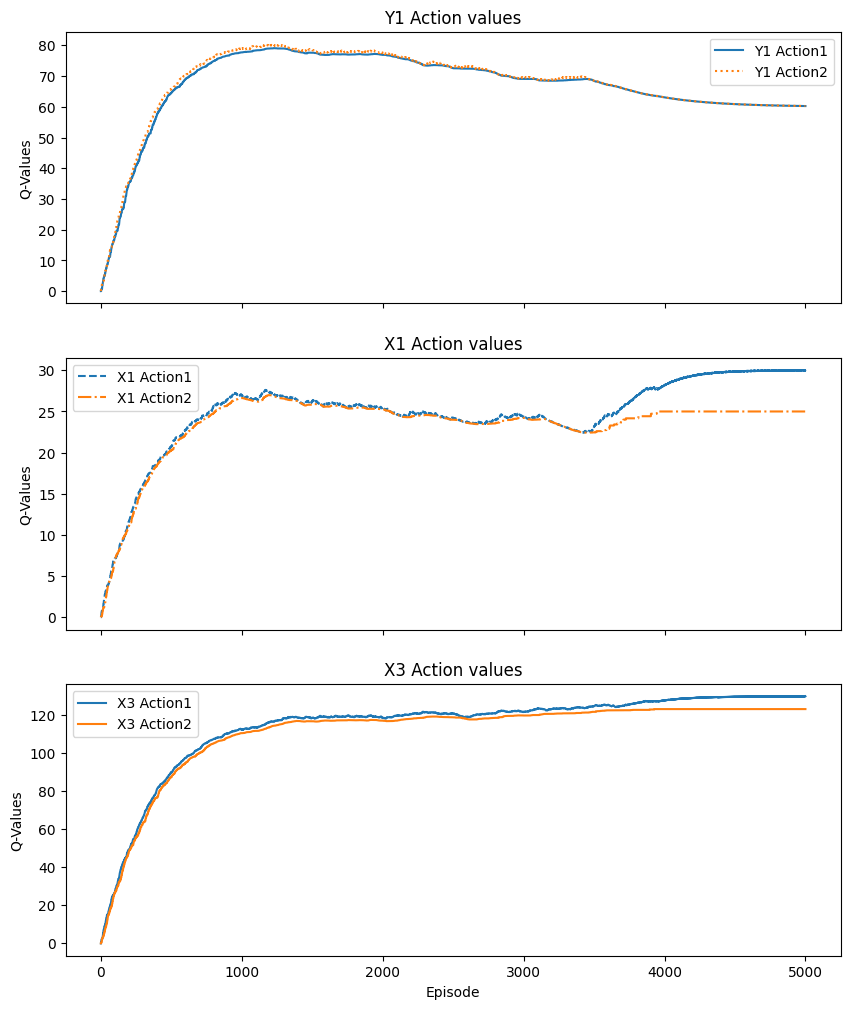

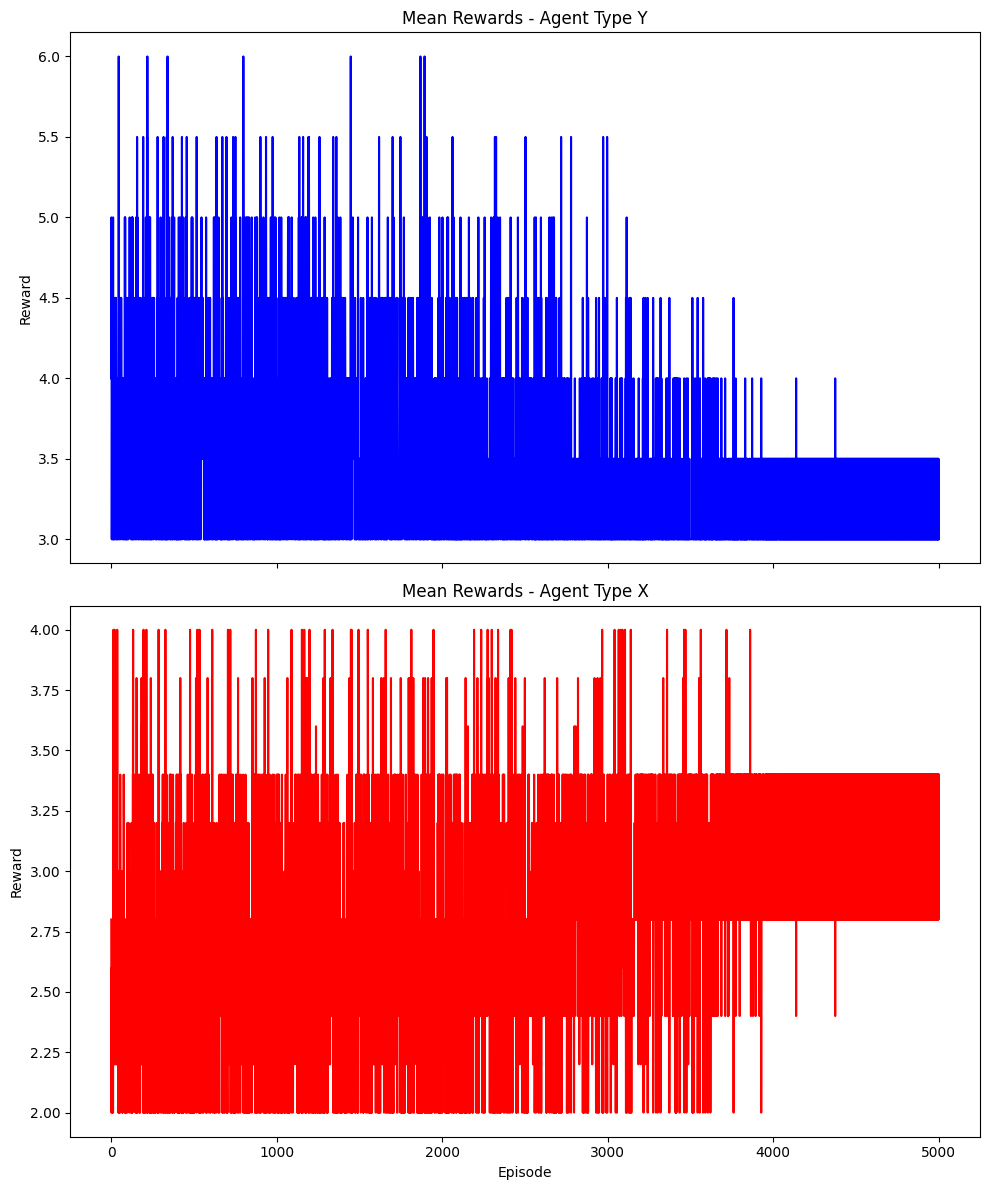

In [13]:
simulate(5000)

## Interpretation

---

# Scenario 2

## Environment implementation

In [17]:


class environment:
    def __init__(self):
        # [[(Row_Payoff, Col_Payoff), ...], ...]
        self.payoff_matrix = [
            [(1, 2), (1, 1)],
            [(1,1), (2,1)]
        ]

      # Define types: X (Column players) and Y (Row players)
        self.agent_types = {
            "X1": "X", "X2": "X", "X3": "X", "X4": "X", "X5": "X",
            "Y1": "Y", "Y2": "Y"
        }

        # Define the djacency graph edges
        self.graph = {
            "X1": ["Y1"],
            "X2": ["Y2"],
            "Y1": ["X1", "X3", "X4"],
            "Y2": ["X2", "X3", "X5"],
            "X3": ["Y1", "Y2", "X4", "X5"],
            "X4": ["Y1", "X3"],
            "X5": ["Y2", "X3"]
        }

        # Epsilon decay parameters

    def reset(self):
        pass

    def step(self, action_matrix):
        """
        Distributes rewards.
        action_matrix = {agent_name: agent_action}
        """

        rewards = {name: 0 for name in self.graph.keys()}

        # Traverse each agent in the graph
        for each_agent in self.graph.keys():
            # Traverse each opponents and calculate rewards
            for each_opponent in self.graph[each_agent]:
                # Extract actions
                act_agent = action_matrix[each_agent] - 1
                act_opp = action_matrix[each_opponent] - 1

                # Extract row column combo from payoff matrix
                if "Y" in each_agent:
                    row_idx, col_idx = act_agent, act_opp

                elif "Y" in each_opponent:
                    row_idx, col_idx = act_opp, act_agent

                else:
                    # Same pair of agents: X vs X
                    row_idx, col_idx = act_agent, act_opp

                # Extract payoff block
                payoff_block = self.payoff_matrix[row_idx][col_idx]

                if "Y" in each_agent:
                    rewards[each_agent] += payoff_block[0]
                else:
                    rewards[each_agent] += payoff_block[1]

        return rewards

## Agent implementation

In [18]:

class QLearningAgent():
    def __init__(self, agent_name, agent_type, actions=[1, 2], epsilon_init=1.0, epsilon_threshold=0.0, epsilon_decay=0.01, alpha=0.01, gamma=0.95):

        self.name = agent_name
        self.type = agent_type # "X" or "Y"
        self.action_space = actions

        # Q-table init - We have dynamic nof opponents here
        self.q_table = {}

        # Hyperparams
        self.epsilon = epsilon_init
        self.epsilon_threshold = epsilon_threshold
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.gamma = gamma

        # Metric tracking
        self.reward_history = []
        self.action_value_history = {1: [], 2: []}

    def _get_q_values_for_state(self, state):
        """ Creates an entry if this neighbor combo is new """

        if state not in self.q_table:
            # Each action (1 and 2) starts at 0.0
            self.q_table[state] = {action: 0.0 for action in self.action_space}
        return self.q_table[state]

    def action(self, state):
        if np.random.rand() < self.epsilon:
            chosen_action = np.random.choice(self.action_space)
        else:
            # Fetch from dynamic state - opponent action
            state_q_values = self._get_q_values_for_state(state)
            max_val = max(state_q_values.values())
            best_action = [a for a, v in state_q_values.items() if v == max_val]
            chosen_action = np.random.choice(best_action)

        return chosen_action

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_threshold:
            self.epsilon -= self.epsilon_decay

    def update_q_values(self, current_state, action, reward, next_state):
        """
        Update Q-table values for agent.
        INPUTS:
            - current_state: neighbor's action @ t-1
            - next_state: neighbor's action @ t
        """
        # 1. Get current Q-value for the (state, action) pair
        current_q = self._get_q_values_for_state(current_state)[action]

        # 2. Look ahead: find max possible Q in next state
        next_state_qs = self._get_q_values_for_state(next_state)
        max_next_q = max(next_state_qs.values())

        # 3. Standard Q-learning formula (Bellman Equation) with state
        # Q(s,a) = Q(s,a) + alpha * [reward + gamma * max(Q(s',a')) - Q(s,a)]
        td_target = reward + (self.gamma * max_next_q)
        self.q_table[current_state][action] += self.alpha * (td_target - current_q)

## Simulation implementation

In [19]:

def simulate(total_episodes):

    # Init metrics
    # Init value tracking
    q_table_values = {"Y1": [], "X1": [], "X3": []}
    mean_history_rewards = {"X": [], "Y": []}

    agent_types = {
        "X1": "X", "X2": "X", "X3": "X", "X4": "X", "X5": "X",
        "Y1": "Y", "Y2": "Y"
    }

    # Init enviromnet
    env = environment()

    # Init agents
    # Define types: X (Column players) and Y (Row players)
    agents = dict()
    for name, agent_type in agent_types.items():
        agents[name] = QLearningAgent(name, agent_type)

    # Initialize opponent moves - start with action 1
    prev_actions = {name: 1 for name in env.agent_types.keys()}

    # Reset env
    env.reset()

    # Simulation start
    for episode in range(total_episodes):
        current_actions = {}

        # Register actions
        for name, agent in agents.items():
            # Fetch agent neighbors
            neighbor_names = env.graph[name]
            # Register neighboring actions as state
            current_state = tuple(prev_actions[nb] for nb in neighbor_names)
            # Register agent action
            current_actions[name] = agent.action(current_state)

        # Step the environment
        rewards = env.step(current_actions)

        # Update Q-values for each agent
        for name, agent in agents.items():
            neighbor_names = env.graph[name]
            # The state we WERE in (at the start of this episode)
            old_state = tuple(prev_actions[nb] for nb in neighbor_names)
            # The state we ARE IN NOW (based on the actions just taken)
            new_state = tuple(current_actions[nb] for nb in neighbor_names)

            # Link State -> Action -> Reward -> Next State
            agent.update_q_values(old_state, current_actions[name], rewards[name], new_state)

        # Register rewards
        x_rewards = [rewards[agent] for agent in rewards if "X" in agent]
        y_rewards = [rewards[agent] for agent in rewards if "Y" in agent]
        mean_history_rewards["X"].append(np.mean(x_rewards))
        mean_history_rewards["Y"].append(np.mean(y_rewards))

        # Register Q-values
        for agent_name in q_table_values.keys():
            # Fetch neighbors
            ref_state = tuple(1 for _ in env.graph[agent_name])
            state_q_vals = agents[agent_name]._get_q_values_for_state(ref_state)
            q_table_values[agent_name].append(dict(state_q_vals))

        # Current actions become previous
        prev_actions = current_actions.copy()

        # Decay epsilon
        if (episode > 0) and (episode % 40 == 0):
            for agent in agents.values():
                agent.decay_epsilon()

    # Plot q-values for Y1,X1,X3
    # For each agent, we need 2 datapoints for the actions
    # Y1
    y1_a1 = [entry[1] for entry in q_table_values["Y1"]]
    y1_a2 = [entry[2] for entry in q_table_values["Y1"]]

    #X1
    x1_a1 = [entry[1] for entry in q_table_values["X1"]]
    x1_a2 = [entry[2] for entry in q_table_values["X1"]]

    #X3
    x3_a1 = [entry[1] for entry in q_table_values["X3"]]
    x3_a2 = [entry[2] for entry in q_table_values["X3"]]

    fig1, axs1 = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # Y1 Plot
    axs1[0].plot(y1_a1, label="Action 1")
    axs1[0].plot(y1_a2, label="Action 2", linestyle="--")
    axs1[0].set_title("Y1 Action Values")
    axs1[0].set(ylabel="Q-Values")
    axs1[0].legend()

    # X1 Plot
    axs1[1].plot(x1_a1, label="Action 1")
    axs1[1].plot(x1_a2, label="Action 2", linestyle="--")
    axs1[1].set_title("X1 Action Values")
    axs1[1].set(ylabel="Q-Values")
    axs1[1].legend()

    # X3 Plot
    axs1[2].plot(x3_a1, label="Action 1")
    axs1[2].plot(x3_a2, label="Action 2", linestyle="--")
    axs1[2].set_title("X3 Action Values")
    axs1[2].set_xlabel("Episode")
    axs1[2].set(ylabel="Q-Values")
    axs1[2].legend()

    # plt.tight_layout()
    # plt.savefig("scenario2_action_values.png")

    #
    # # Plotting - mean rewards for 2 agent types
    fig2, (ax_y, ax_x) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

    ax_y.plot(mean_history_rewards["Y"], color="blue", label="Type Y")
    ax_y.set_title("Mean Rewards - Agent Type Y")
    ax_y.set_ylabel("Reward")

    ax_x.plot(mean_history_rewards["X"], color="red", label="Type X")
    ax_x.set_title("Mean Rewards - Agent Type X")
    ax_x.set_ylabel("Reward")
    ax_x.set_xlabel("Episode")

    plt.tight_layout()
    # plt.savefig("scenario2_average_rewards.png")
    # plt.close(fig2)

    plt.show(fig1)
    plt.show(fig2)

## Simulation results

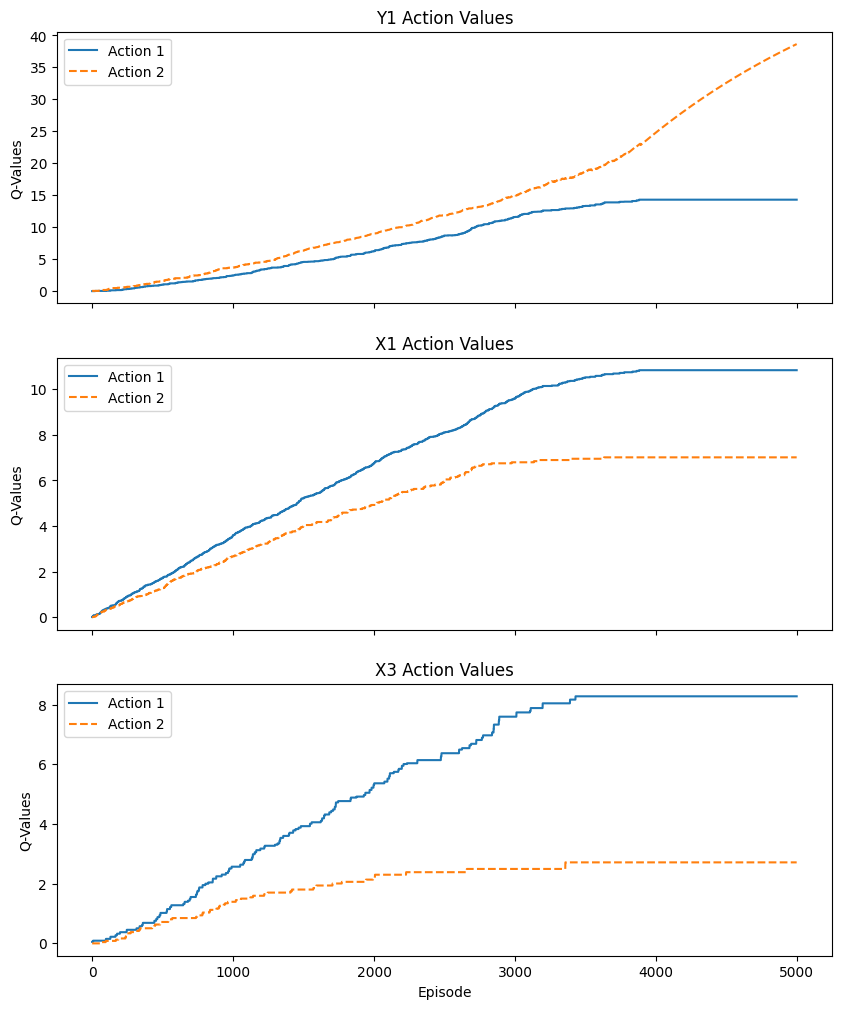

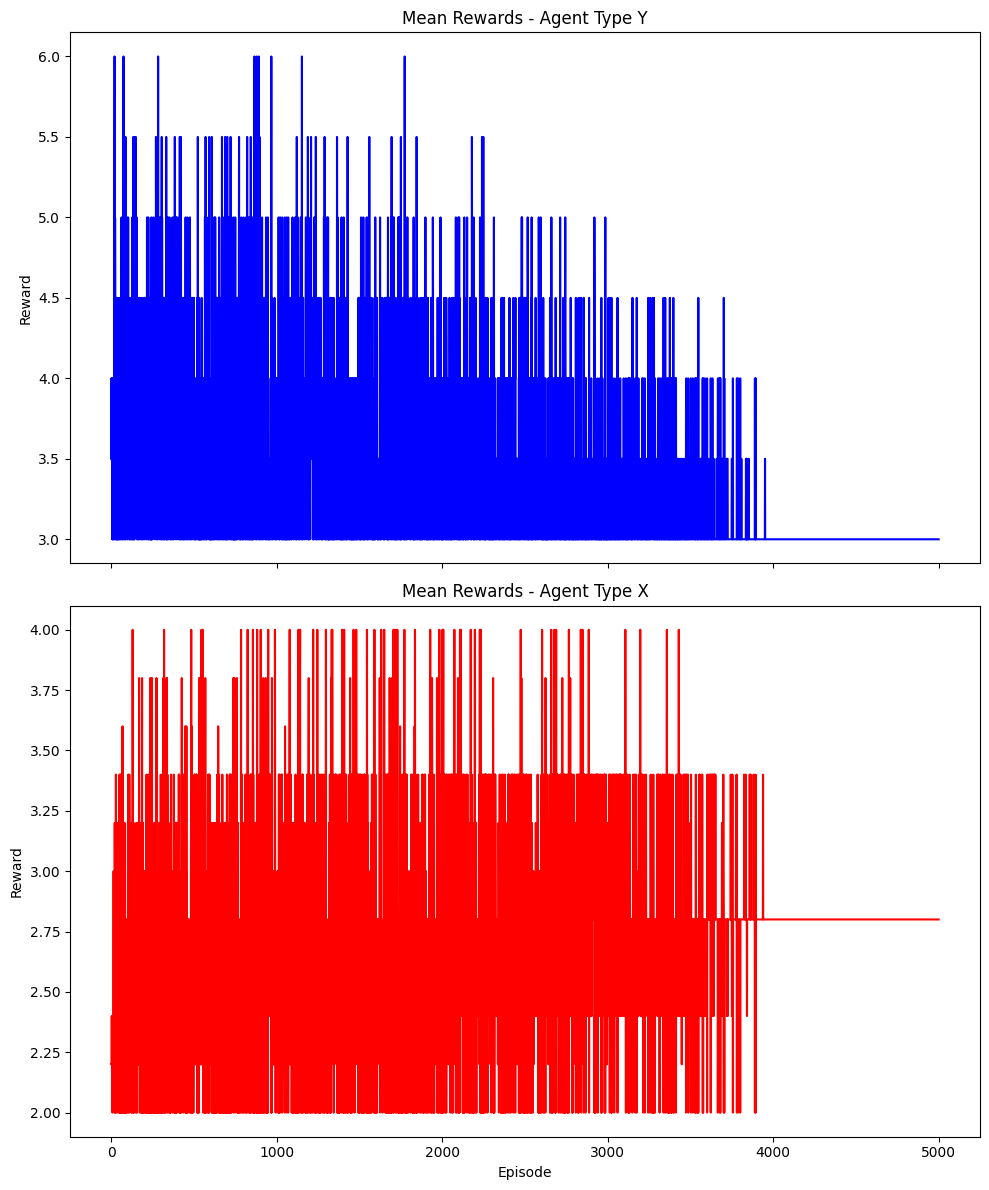

In [20]:
simulate(5000)